## Surface Evap and Masked Surface Evap

### Read in ERA5 and create a surface evap + land masked surface evap array

**not using ERA5 Land in this code**

**doing hourly integrations of Fx and Fy before taking monthly mean**



In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import scipy
import sys 
import warnings
import matplotlib.pyplot as plt
from shapely.geometry import mapping
import cartopy.crs as ccrs
import cartopy.feature
warnings.filterwarnings('ignore')
import time as timer
start_all = timer.time()

In [2]:
dataf ="/Volumes/ESA_F4R/era/" 
datao ="/Volumes/ESA_F4R/ed_prepare/" 
datap ="/Users/ellendyer/Library/Mobile Documents/com~apple~CloudDocs/1SHARED_WORK/Work/3_ESA_GRANT/MODEL/plots/era/"

In [3]:
#For selection and plotting
YR = 1994
time_bnds = (str(YR)+'-01-01',str(YR)+'-12-31')
lon_bnds, lat_bnds = (8, 31), (12,-15)
lon_bnds_f, lat_bnds_f = (8, 31), (-15,12) 
p_bnds = (30000,100000)

**Read in ERA5 data on pressure levels (hourly timesteps in fortnightly files)**
- *fortnightly files currently run from 1994-2024*
- resampled to monthly MS timestep
- shum multiplied by 1000 to convert from kg/kg --> g/kg
- pressure levels are divided by 100 to convert from Pa to hPa (only for fortnightly files)
- sort data by descending pressure levels (only for fortnightly files)


**Input file units:**
- plev - pa
- q - kg/kg
- u - m/s
- v - m/s

In [ ]:
start = timer.time()
from functools import partial
def _preprocess_pres(x, lon_bnds, lat_bnds, p_bnds):
    return x.sel(lon=slice(*lon_bnds), lat=slice(*lat_bnds),
                 plev=slice(*p_bnds),drop=True)
partial_func_pres = partial(_preprocess_pres, lon_bnds=lon_bnds, lat_bnds=lat_bnds, p_bnds=p_bnds)

#Reading in pressure level variables from ERA5
ds_era_pres = xr.open_mfdataset(dataf+"era5/pressure_levels/era5_pressure_level_variables_central_africa_"+str(YR)+"*.nc",
                                drop_variables=['r','t','w'],
                                preprocess=partial_func_pres,parallel=True).load()
ds_era_pres = ds_era_pres.rename({'plev':'level','q':'Shum','u':'Uwnd','v':'Vwnd'})
ds_era_pres['Shum'] = 1000.0*ds_era_pres['Shum']
ds_era_pres['level'] = ds_era_pres['level']/100.0  
ds_era_pres = ds_era_pres.sortby('level', ascending=False) 
end = timer.time()
length = end - start
print("ERA5 pressure level data read in took ", length, "seconds")

**Read in ERA5 land-sea mask to use to create a land only version of surface evaporation**

Values greater than 0 are land values which can include water bodies on land such as rivers

<xarray.DataArray 'lsm' (lat: 1801, lon: 3600)> Size: 52MB
[6483600 values with dtype=float64]
Coordinates:
  * lon      (lon) float32 14kB 0.0 0.1 0.2 0.3 0.4 ... 359.6 359.7 359.8 359.9
  * lat      (lat) float32 7kB 90.0 89.9 89.8 89.7 ... -89.7 -89.8 -89.9 -90.0
Attributes:
    units:          (0 - 1)
    long_name:      Land-sea mask
    standard_name:  land_binary_mask


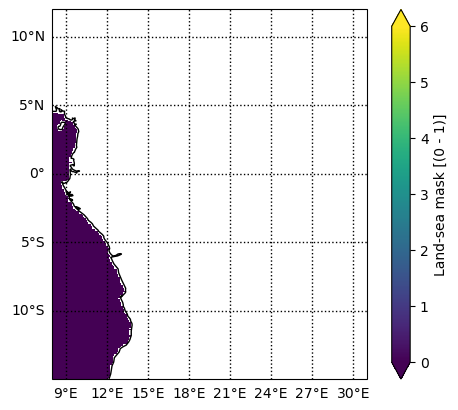

<Figure size 640x480 with 0 Axes>

In [ ]:
mask = xr.open_dataset("/Users/ellendyer/Documents/GitHub/f4r-bulk-recycling-model/lsm_1279l4_0.1x0.1.grb_v4_unpack.nc")['lsm']
mask = mask.rename({'latitude':'lat','longitude':'lon'})
mask = mask.squeeze(['time'], drop=True)
print(mask)

mask = mask.where(mask.lon<24.0,1)

water = mask.where(mask==0.0,drop=True)

ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cartopy.feature.OCEAN)
water.plot(ax=ax,transform=ccrs.PlateCarree(),
                                       add_colorbar=True,
                                       vmin=0,vmax=6,
                                       alpha=1,
                                       cmap=plt.cm.viridis,
                                       extend="both")
ax.set_extent([8, 31, -15, 12])
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=1, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('')
#plt.savefig()
plt.show()
plt.clf()

* * * **Not using ERA5 land but keeping the note as the accumulation for ERA5 surface is different - note below**

**Read in ERA5 land data (hourly in monthly files)**
- selecting hour 23 (0-23) of Prec and Evap because of how ERA5 Land variables are accumulated (https://confluence.ecmwf.int/pages/viewpage.action?pageId=197702790 - https://confluence.ecmwf.int/display/CKB/ERA5-Land%3A+data+documentation#ERA5Land:datadocumentation-accumulationsAccumulations)
- prec is multiplied by 1000 to convert from m to mm
- evap is multiplied by -1000 to convert from m to mm and upward fluxes in land model are considered negative
- Prec, Evap, and Psfc are then resampled to MS monthly and also interpolated to coarser pressure level grid

**Input file units:**
- tp - m
- e - m (-)
- sp - pa

**Read in ERA5 surface variables (hourly in monthly files)**
- these files are also accumulation but they are per timestep so the value should be a sum over the day rather than the last time step
- https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview 


Read in ERA5 surface vars for merging - setting non land evaporation to zero. Merging surface pressure level and land surface pressure to output. 

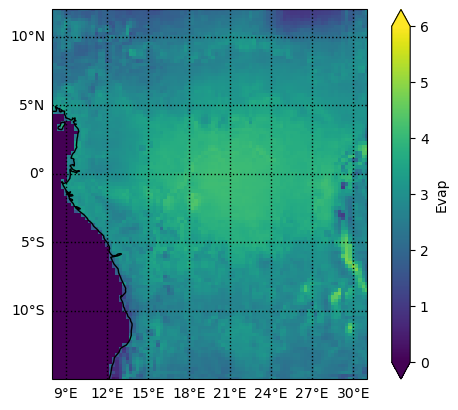

ERA5 surface data read in took  23.098764181137085 seconds


<Figure size 640x480 with 0 Axes>

In [ ]:
start = timer.time()

from functools import partial
def _preprocess_land(x, lon_bnds, lat_bnds):
    x = x.sel(longitude=slice(*lon_bnds), latitude=slice(*lat_bnds),drop=True)
    return x
partial_func_land = partial(_preprocess_land, lon_bnds=lon_bnds, lat_bnds=lat_bnds)

#Reading in surface variables from ERA5 surface files
ds_era_psfc = xr.open_mfdataset(dataf+"era5/era5_surface/era5_surface_pressure_central_africa_"+str(YR)+"*.nc",
                                drop_variables=['expver','number'],
                                preprocess=partial_func_land,parallel=True).load()
ds_era_psfc = ds_era_psfc.rename({'valid_time':'time','latitude':'lat',
                                  'longitude':'lon','sp':'Psfc'})
#ds_era_psfc = ds_era_psfc.interp(lat=ds_era_pres['lat'],lon=ds_era_pres['lon'],method='linear',kwargs={"fill_value": "extrapolate"})
Psfc_surface = ds_era_psfc['Psfc']/100.0
ds_era_psfc.close()

ds_era_evap = xr.open_mfdataset(dataf+"era5/era5_surface/era5_evaporation_central_africa_"+str(YR)+"*.nc",
                                drop_variables=['expver','number'],
                                preprocess=partial_func_land,parallel=True).load()
ds_era_evap = ds_era_evap.rename({'valid_time':'time','latitude':'lat',
                                  'longitude':'lon','e':'Evap'})
#ds_era_evap = ds_era_evap.interp(lat=ds_era_pres['lat'],lon=ds_era_pres['lon'],method='linear',kwargs={"fill_value": "extrapolate"})
Evap_surface = ds_era_evap.resample(time='D').sum(dim='time')*-1000.0
ds_era_evap.close()

Evap_all = Evap_surface
mask_surf = mask.interp(lat=Evap_surface['lat'],lon=Evap_surface['lon'],method='linear',kwargs={"fill_value": "extrapolate"})
Evap_land = Evap_surface.where(mask_surf!=0.0,0,0)


ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cartopy.feature.OCEAN)
Evap_land['Evap'].mean('time').plot(ax=ax,transform=ccrs.PlateCarree(),
                                       add_colorbar=True,
                                       vmin=0,vmax=6,
                                       alpha=1,
                                       cmap=plt.cm.viridis,
                                       extend="both")
ax.set_extent([8, 31, -15, 12])
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=1, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('')
#plt.savefig()
plt.show()
plt.clf()

EvapL = xr.Dataset({"Evap_land":Evap_land['Evap']})
EvapA = xr.Dataset({"Evap_all":Evap_all['Evap']})
Psfc = Psfc_surface

end = timer.time()
length = end - start
print("ERA5 surface data read in took ", length, "seconds")

## Plotting the different evaporation arrays

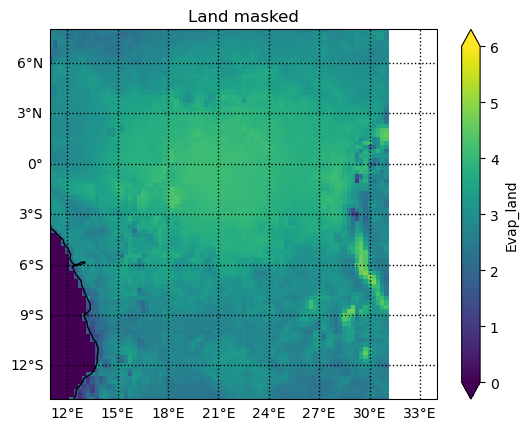

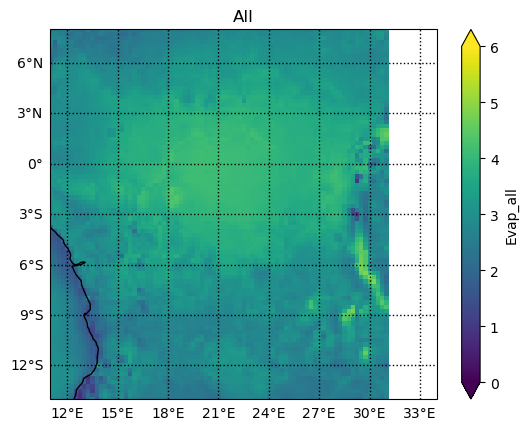

<Figure size 640x480 with 0 Axes>

In [ ]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cartopy.feature.OCEAN)
EvapL['Evap_land'].mean('time').plot(ax=ax,transform=ccrs.PlateCarree(),
                                       add_colorbar=True,
                                       vmin=0,vmax=6,
                                       alpha=1,
                                       cmap=plt.cm.viridis,
                                       extend="both")
ax.set_extent([11, 34, -14, 8])
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=1, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('Land masked')
#plt.savefig()
plt.show()
plt.clf()


ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
#ax.add_feature(cartopy.feature.OCEAN)
EvapA['Evap_all'].mean('time').plot(ax=ax,transform=ccrs.PlateCarree(),
                                       add_colorbar=True,
                                       vmin=0,vmax=6,
                                       alpha=1,
                                       cmap=plt.cm.viridis,
                                       extend="both")
ax.set_extent([11, 34, -14, 8])
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='black', alpha=1, linestyle='dotted')
gl.top_labels = False
gl.right_labels = False
ax.set_title('All')
#plt.savefig()
plt.show()
plt.clf()


**Merging all input datasets into one dataset for recyling code called ds**
- close both input datasets
- sort everything so latitude is south to north
- transpose dimensions so they run (lon,lat,level,time) as in recycling code
- save input ds to file

In [ ]:
start = timer.time()
ds = xr.merge([ds_era_pres,EvapL,EvapA,Psfc]) 
ds_era_pres.close()
ds = ds.sortby('lat', ascending=True)
ds = ds.sel(lat=slice(*lat_bnds_f),lon=slice(*lon_bnds_f))


Merging and dataset output took  1.5922701358795166 seconds


In [ ]:
import bulk_recycling_model.numerical_integration

# Integrate 10^-3 Shum Uwnd dp
# Because the integration limits are from high pressure to low pressure, we need to invert the sign.
integrand = -1 * 1e-3 * ds["Shum"] * ds["Uwnd"]
Fx = bulk_recycling_model.numerical_integration.integrate_with_extrapolation(integrand, ds["Psfc"])
# Units: mb x m/s

# Integrate 10^-3 Shum Vwnd dp
# Because the integration limits are from high pressure to low pressure, we need to invert the sign.
integrand = -1 * 1e-3 * ds["Shum"] * ds["Vwnd"]
Fy = bulk_recycling_model.numerical_integration.integrate_with_extrapolation(integrand, ds["Psfc"])
# Units: mb x m/s

In [ ]:
ds = ds.resample(time='MS').mean(dim='time')
ds = ds.transpose("lon", "lat", "level", "time",missing_dims='ignore')

In [ ]:
ds.to_netcdf(datao+"merge_erads_SE_ID_"+str(YR)+".nc", mode='w', format='NETCDF4', engine='netcdf4')
end = timer.time()
length = end - start
print("Merging and dataset output took ", length, "seconds")

In [ ]:

print(ds)

<xarray.Dataset> Size: 33MB
Dimensions:    (time: 12, level: 20, lat: 109, lon: 93)
Coordinates:
  * lon        (lon) float64 744B 8.0 8.25 8.5 8.75 ... 30.25 30.5 30.75 31.0
  * lat        (lat) float64 872B -15.0 -14.75 -14.5 -14.25 ... 11.5 11.75 12.0
  * level      (level) float64 160B 1e+03 975.0 950.0 ... 400.0 350.0 300.0
  * time       (time) datetime64[ns] 96B 1994-01-01 1994-02-01 ... 1994-12-01
Data variables:
    Shum       (lon, lat, level, time) float32 10MB 11.6 12.62 ... 0.1681 0.1087
    Uwnd       (lon, lat, level, time) float32 10MB -1.103 -1.48 ... 7.401
    Vwnd       (lon, lat, level, time) float32 10MB 4.812 4.61 ... -0.6162
    Prec       (lon, lat, time) float64 973kB nan nan nan ... -0.02823 0.0009287
    Evap_land  (lon, lat, time) float64 973kB 0.0 0.0 0.0 ... 4.457 3.981 1.933
    Evap_all   (lon, lat, time) float64 973kB 0.0 0.0 0.0 ... 4.457 3.981 1.933
    Psfc       (lon, lat, time) float64 973kB 1.012e+03 1.012e+03 ... 913.6
Attributes:
    CDI:       